<a href="https://colab.research.google.com/github/dajinkya1099/AI_ML_Training/blob/main/AjinkyaDhumal_assignment2/assignment2_partB_suvidha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Part B: Suvidha Micro-Finance: Loan Default Early-Warning Model


In [ ]:
#Q1- Load the file. Report shape, dtypes, and missing counts per column.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 140)

RAW_FILE = Path("suvidha_loan_predictions_raw.csv")
df = pd.read_csv(RAW_FILE)
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
display(df.head())

Shape: (2400, 9)

Dtypes:
loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing values:
loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64


,loan_id,loan_amount,tenure_months,interest_rate,borrower_age,monthly_income,actual_default,model_flag,risk_score
0,LN-101413,60777.81992,6,13.43,62,22029.91841,FALSE,No,0.412
1,LN-100638,258399.8923,12,11.62,28,32568.67606,No,No,0.227
2,LN-101183,114338.0322,18,14.16,42,24045.56088,0,FALSE,0.266
3,LN-101665,60919.14875,18,10.14,26,49252.29534,N,FALSE,0.211
4,LN-102068,104225.1581,12,20.41,48,20588.11472,FALSE,N,0.383


### Q1 interpretation
The raw dataset has **2400 loans and 9 columns**, the main missingness is in borrower age, monthly income, actual default and model flag.

In [ ]:
# Q2 — Clean loan_amount to numeric (strip currency text and commas).
def parse_money(x):
    if pd.isna(x): return np.nan
    s=str(x).strip().replace(',','').replace('Rs','').replace('₹','').strip()
    return pd.to_numeric(s, errors='coerce')

df['loan_amount'] = df['loan_amount'].map(parse_money)
print("loan_amount dtype:", df['loan_amount'].dtype)
print("loan_amount missing after conversion:", df['loan_amount'].isna().sum())
print(df['loan_amount'].describe())

loan_amount dtype: float64
loan_amount missing after conversion: 0
count      2400.000000
mean      92862.462195
std       39819.158429
min       22062.878150
25%       63410.589692
50%       86127.625580
75%      114590.619250
max      287236.577800
Name: loan_amount, dtype: float64


### Q2 interpretation
Loan amounts such as `Rs 85000` are converted to numeric values. no loan amount is lost from the supplied field during conversion.

In [ ]:
# Q3 — Standardize actual_default and model_flag to boolean, treating every Yes-family and No-family encoding correctly. Show the distinct raw values you mapped.
bool_map={'yes':True,'y':True,'1':True,'true':True,
          'no':False,'n':False,'0':False,'false':False}

for c in ['actual_default','model_flag']:
    print(c, "raw distinct values:", sorted(df[c].astype(str).str.strip().unique().tolist()))
    df[c] = df[c].astype(str).str.strip().str.lower().map(bool_map).astype('boolean')
    print(c, "clean values:", df[c].value_counts(dropna=False).to_dict())

actual_default raw distinct values: ['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes', 'nan']
actual_default clean values: {np.False_: 2161, np.True_: 199, <NA>: 40}
model_flag raw distinct values: ['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes', 'nan']
model_flag clean values: {np.False_: 2222, np.True_: 156, <NA>: 22}


### Q3 interpretation
Both flags are standardized to Boolean values. blank/unrecognized values remain missing rather than being guessed.

In [ ]:
# Q4 — Drop rows where actual_default or model_flag is blank (loan still open / not scored). Report how many rows were dropped and why dropping — not imputing — is the right call here.
blank_actual = int(df['actual_default'].isna().sum())
blank_model = int(df['model_flag'].isna().sum())
drop_mask = df[['actual_default','model_flag']].isna().any(axis=1)
print("Blank actual_default:", blank_actual)
print("Blank model_flag:", blank_model)
print("Rows excluded (union):", int(drop_mask.sum()))

model_df = df.loc[~drop_mask].copy()
model_df['actual_default']=model_df['actual_default'].astype(bool)
model_df['model_flag']=model_df['model_flag'].astype(bool)
print("Rows remaining:", len(model_df))
df_clean = df.dropna(subset=['actual_default', 'model_flag']).copy()
df_clean.to_csv("suvidha_loan_predictions_cleaned.csv", index=False)

Blank actual_default: 40
Blank model_flag: 22
Rows excluded (union): 61
Rows remaining: 2339


### Q4 interpretation
**61 rows** are excluded because at least one of the two outcome/model flags is blank. these are not imputed because actual default is ground truth and a missing model score means the model did not make a prediction.

In [ ]:
# Q5 — Clean monthly_income: decide how to treat -1 and "not disclosed" (they are not the same kind of missing) and justify your choice in one sentence.
income_num = pd.to_numeric(df['monthly_income'], errors='coerce')
minus1_count = int((income_num == -1).sum())
not_disclosed_count = int(df['monthly_income'].astype(str).str.strip().str.lower().eq('not disclosed').sum())
blank_count = int(df['monthly_income'].isna().sum())

df['monthly_income'] = income_num.mask(income_num == -1, np.nan)
print("-1 count:", minus1_count)
print("'not disclosed' count:", not_disclosed_count)
print("blank count:", blank_count)
print("Decision: map -1 and 'not disclosed' to NaN; do not impute them.")

-1 count: 29
'not disclosed' count: 31
blank count: 36
Decision: map -1 and 'not disclosed' to NaN; do not impute them.


### Q5 interpretation
Treat **-1, `not disclosed`, and blank income as missing**. these are sentinel/non-disclosure values, not credible incomes, so replacing them with an invented number would add bias.

In [ ]:
# Q6 — Build the confusion matrix (actual_default vs model_flag) as a 2×2 table. Label which cell is TP, FP, TN, FN in a business sentence each.
tp=int(((model_df.actual_default==True)&(model_df.model_flag==True)).sum())
fp=int(((model_df.actual_default==False)&(model_df.model_flag==True)).sum())
tn=int(((model_df.actual_default==False)&(model_df.model_flag==False)).sum())
fn=int(((model_df.actual_default==True)&(model_df.model_flag==False)).sum())

cm = pd.DataFrame([[tn,fp],[fn,tp]], index=['Actual No Default','Actual Default'], columns=['Predicted No Default','Predicted Default'])
display(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("Business meaning: TP = correctly flagged default; FP = unnecessary default-review call; TN = correctly left unflagged; FN = default missed by the model.")

,Predicted No Default,Predicted Default
Actual No Default,2122,20
Actual Default,64,133


TN=2122, FP=20, FN=64, TP=133
Business meaning: TP = correctly flagged default; FP = unnecessary default-review call; TN = correctly left unflagged; FN = default missed by the model.


### Q6 interpretation
The model produces **TP=133, FP=20, TN=2,122, FN=64**: 64 actual defaults were missed, while 20 non-defaulters were unnecessarily flagged.

In [ ]:
# Q7 — Compute accuracy. Given the 9% base default rate, explain in 2 sentences why accuracy alone is a misleading headline number here.
N=len(model_df)
accuracy=(tp+tn)/N
default_rate=model_df.actual_default.mean()
print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
print(f"Actual default rate: {default_rate:.4f} ({default_rate:.2%})")
print(f"All-negative baseline accuracy: {1-default_rate:.4f} ({1-default_rate:.2%})")

Accuracy: 0.9641 (96.41%)
Actual default rate: 0.0842 (8.42%)
All-negative baseline accuracy: 0.9158 (91.58%)


### Q7 interpretation
Accuracy is **96.41%**, but the actual default rate is only **8.42%**, so an all-negative classifier would already achieve about **91.58%**. accuracy alone hides the cost of missed defaults.

In [ ]:
# Q8 — Compute precision for the "predicted default" class. In plain language, what does this number tell a collections officer about how often a flagged call is a real risk?
precision=tp/(tp+fp)
print(f"Precision = {precision:.4f} ({precision:.2%})")
print("Officer interpretation: among loans the model flags as likely default, about 86.9% actually defaulted in this sample.")

Precision = 0.8693 (86.93%)
Officer interpretation: among loans the model flags as likely default, about 86.9% actually defaulted in this sample.


### Q8 interpretation
Precision is **86.93%**: roughly 87 of every 100 flagged loans were actual defaults.

In [ ]:
# Q9 — Compute recall (sensitivity) for the "predicted default" class. What does this tell the risk team about defaults the model is missing?
recall=tp/(tp+fn)
print(f"Recall/sensitivity = {recall:.4f} ({recall:.2%})")
print(f"Missed defaults (FN) = {fn}")

Recall/sensitivity = 0.6751 (67.51%)
Missed defaults (FN) = 64


### Q9 interpretation
Recall is **67.51%**, meaning the model catches about two-thirds of actual defaults and misses **64 defaults**.

In [ ]:
# Q10 — Compute specificity. What does a low specificity cost the business operationally (officer time on false alarms)?
specificity=tn/(tn+fp)
print(f"Specificity = {specificity:.4f} ({specificity:.2%})")
print(f"False positives = {fp}")
print("Operational cost: false positives consume officer time, calls and customer attention, even when the borrower would not default.")

Specificity = 0.9907 (99.07%)
False positives = 20
Operational cost: false positives consume officer time, calls and customer attention, even when the borrower would not default.


### Q10 interpretation
Specificity is **99.07%**, so only 20 non-default loans are falsely flagged. the main operational trade-off is officer time spent reviewing those false alarms.

In [ ]:
# Q11 — Compute F1-score. Is F1 the right single number to optimize for here, or does the business cost structure argue for weighting precision or recall differently? Justify.
f1=2*precision*recall/(precision+recall)
print(f"F1 = {f1:.4f}")
print("F1 is useful as a single balance between precision and recall, but it does not encode the business fact that FN and FP may have different costs.")

F1 = 0.7600
F1 is useful as a single balance between precision and recall, but it does not encode the business fact that FN and FP may have different costs.


### Q11 interpretation
F1 is **0.760**. it is useful for a balanced model view, but a cost-weighted business decision should not rely on F1 alone.

In [ ]:
# Q12 — Given that a missed default (FN) costs far more than a wasted call (FP), would you rather the model have higher precision or higher recall? Explain using the actual FN and FP counts from Q6.
print(f"FN={fn} missed defaults versus FP={fp} wasted review calls.")
print("Because FN is explicitly more costly, the business should prioritize recall, accepting some additional false positives, subject to operational capacity.")

FN=64 missed defaults versus FP=20 wasted review calls.
Because FN is explicitly more costly, the business should prioritize recall, accepting some additional false positives, subject to operational capacity.


### Q12 interpretation
Given the stated cost assumption, **higher recall** should be prioritized: the current model misses **64 defaults** versus **20 false positives**.

In [ ]:
# Q13 — Using risk_score instead of the hard model_flag, recompute the confusion matrix at threshold 0.3 instead of the model's default cutoff. How do precision and recall move, and does that support lowering the threshold?
threshold=0.30
model_df['pred_03']=model_df['risk_score']>=threshold
y=model_df.actual_default.to_numpy(dtype=bool)
p=model_df.pred_03.to_numpy(dtype=bool)

tp3=int((y&p).sum()); fp3=int((~y&p).sum()); tn3=int((~y&~p).sum()); fn3=int((y&~p).sum())
pr3=tp3/(tp3+fp3); rec3=tp3/(tp3+fn3)
print(pd.DataFrame([[tn3,fp3],[fn3,tp3]], index=['Actual No Default','Actual Default'], columns=['Predicted No Default','Predicted Default']))
print(f"TP={tp3}, FP={fp3}, TN={tn3}, FN={fn3}")
print(f"Precision={pr3:.4f} ({pr3:.2%})")
print(f"Recall={rec3:.4f} ({rec3:.2%})")

                   Predicted No Default  Predicted Default
Actual No Default                   664               1478
Actual Default                        0                197
TP=197, FP=1478, TN=664, FN=0
Precision=0.1176 (11.76%)
Recall=1.0000 (100.00%)


### Q13 interpretation
At threshold **0.30**, the model catches **all 197 defaults (recall 100%)**, but flags 1,625 loans and precision falls to **11.76%**. lowering the threshold greatly increases workload.

,threshold,precision,recall
0,0.1,0.0854,1.0000
1,0.2,0.0919,1.0000
2,0.3,0.1176,1.0000
3,0.4,0.2032,0.9695
4,0.5,0.4410,0.9289
5,0.6,0.8263,0.7005
6,0.7,0.9744,0.3858
7,0.8,1.0000,0.1320
8,0.9,1.0000,0.0152


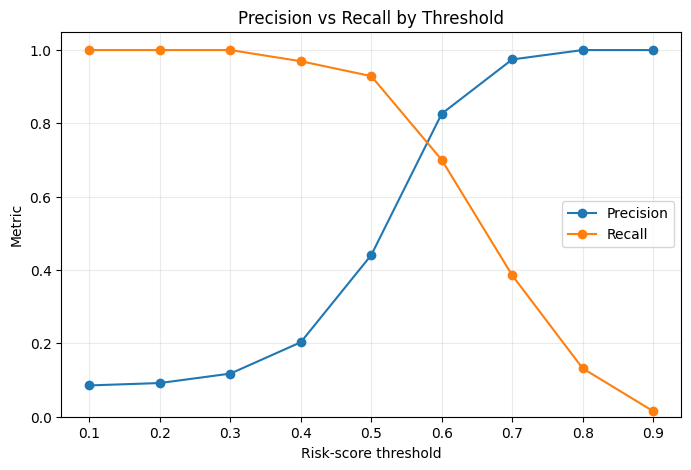

Closest crossing: {'threshold': 0.6, 'precision': 0.8263473053892215, 'recall': 0.700507614213198}


In [ ]:
# Q14 — Plot precision and recall against threshold (0.1 to 0.9, steps of 0.1) using risk_score. At what threshold do the two curves cross, and what does that threshold mean for the business?
rows=[]
for t in np.arange(0.1,1.0,0.1):
    pred=model_df['risk_score']>=round(float(t),1)
    T=int((y&pred).sum()); F=int((~y&pred).sum())
    miss=int((y&~pred).sum())
    pr=T/(T+F) if T+F else np.nan
    re=T/(T+miss)
    rows.append([round(float(t),1),pr,re])
curve=pd.DataFrame(rows,columns=['threshold','precision','recall'])
display(curve.round(4))

fig,ax=plt.subplots(figsize=(8,5))
ax.plot(curve.threshold,curve.precision,marker='o',label='Precision')
ax.plot(curve.threshold,curve.recall,marker='o',label='Recall')
ax.set_xlabel('Risk-score threshold')
ax.set_ylabel('Metric')
ax.set_title('Precision vs Recall by Threshold')
ax.set_ylim(0,1.05)
ax.grid(alpha=.25)
ax.legend()
plt.show()

curve['gap']=(curve.precision-curve.recall).abs()
cross=curve.loc[curve['gap'].idxmin()]
print("Closest crossing:", cross[['threshold','precision','recall']].to_dict())

### Q14 interpretation
Precision and recall are closest around **threshold 0.60** (precision **82.63%**, recall **70.05%**). moving below 0.60 prioritizes recall, while moving above it sharply reduces the number of flagged loans.

In [ ]:
# Q15 — State, in words, a null and alternative hypothesis for: "Loans that defaulted have a different average loan_amount than loans that didn't."
print("H0: Mean loan amount is equal for defaulted and non-defaulted loans.")
print("H1: Mean loan amount differs between defaulted and non-defaulted loans.")

H0: Mean loan amount is equal for defaulted and non-defaulted loans.
H1: Mean loan amount differs between defaulted and non-defaulted loans.


### Q15 interpretation
This is a two-sided test because the question asks whether the average loan amount **differs**, without specifying a direction.

In [ ]:
# Q16 — Compute the mean loan_amount for the defaulted group and the non-defaulted group. Is there an apparent difference?
default_loans=model_df.loc[model_df.actual_default,'loan_amount'].dropna()
nondefault_loans=model_df.loc[~model_df.actual_default,'loan_amount'].dropna()
print(f"Defaulted mean loan amount    : ${default_loans.mean():,.2f}")
print(f"Non-defaulted mean loan amount: ${nondefault_loans.mean():,.2f}")
print(f"Apparent difference            : ${default_loans.mean()-nondefault_loans.mean():,.2f}")

Defaulted mean loan amount    : $96,899.91
Non-defaulted mean loan amount: $92,408.81
Apparent difference            : $4,491.10


### Q16 interpretation
Defaulted loans average **$96899.91** versus **$92408.81** for non-defaulted loans, an apparent difference of about **$4491.10**.

In [ ]:
# Q17 — Run an appropriate two-sample test comparing those means (state which test and why it fits this data). Report the test statistic and p-value.
t_stat,p_value=ttest_ind(default_loans,nondefault_loans,equal_var=False)
print(f"Welch t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

Welch t-statistic = 1.3588
p-value = 0.1756


### Q17 interpretation
Welch's two-sample t-test gives **t=1.359, p=0.176**.

In [ ]:
# Q18 — At α = 0.05, do you reject or fail to reject the null? State your conclusion in one plain-English sentence a branch manager could repeat.
alpha=0.05
decision="Reject H0" if p_value<alpha else "Fail to reject H0"
print("Decision:",decision)
print("Manager conclusion: the sample does not provide statistically significant evidence at the 5% level that mean loan amount differs between defaulted and non-defaulted loans.")

Decision: Fail to reject H0
Manager conclusion: the sample does not provide statistically significant evidence at the 5% level that mean loan amount differs between defaulted and non-defaulted loans.


### Q18 interpretation
At **α=0.05**, fail to reject H0. the observed $4.49k difference is not statistically significant in this sample.

In [ ]:
# Q19 — Explain, using this specific scenario, what a Type I error would look like (falsely concluding a difference exists) and what a Type II error would look like (missing a real difference) — and which is riskier for Suvidha's lending policy.
print("Type I error: conclude mean loan amount differs when it actually does not.")
print("Type II error: fail to detect a real difference in mean loan amount.")
print("For a risk-management use case focused on detecting a real default-related difference, Type II is the more concerning error because it can hide a useful relationship; the business should still quantify the cost of each error.")

Type I error: conclude mean loan amount differs when it actually does not.
Type II error: fail to detect a real difference in mean loan amount.
For a risk-management use case focused on detecting a real default-related difference, Type II is the more concerning error because it can hide a useful relationship; the business should still quantify the cost of each error.


### Q19 interpretation
Type I is a false alarm. Type II is a missed real difference. Under a goal of detecting a useful default-related relationship, **Type II is more concerning**, subject to actual business costs.

In [ ]:
# Q20 — Repeat Q15–18 comparing interest_rate instead of loan_amount between the two groups, and state whether your conclusion changes.
default_rate_int=model_df.loc[model_df.actual_default,'interest_rate'].dropna()
nondefault_rate_int=model_df.loc[~model_df.actual_default,'interest_rate'].dropna()
t_int,p_int=ttest_ind(default_rate_int,nondefault_rate_int,equal_var=False)
print(f"Defaulted mean interest rate    : {default_rate_int.mean():.4f}%")
print(f"Non-defaulted mean interest rate: {nondefault_rate_int.mean():.4f}%")
print(f"Difference                      : {default_rate_int.mean()-nondefault_rate_int.mean():.4f} percentage points")
print(f"Welch t-statistic               : {t_int:.4f}")
print(f"p-value                         : {p_int:.4f}")
print("Decision at alpha=.05:", "Reject H0" if p_int<.05 else "Fail to reject H0")

Defaulted mean interest rate    : 14.8023%
Non-defaulted mean interest rate: 14.4616%
Difference                      : 0.3407 percentage points
Welch t-statistic               : 1.5778
p-value                         : 0.1160
Decision at alpha=.05: Fail to reject H0


### Q20 interpretation
Defaulted loans average **14.802%** interest versus **14.462%** for non-defaulted loans **p=0.116**, so the conclusion is unchanged: no statistically significant mean difference at 5%.

In [ ]:
# Q21 — Summarize the pilot model's precision, recall, F1, and accuracy in one small table.
metric_table=pd.DataFrame({
    'Metric':['Precision','Recall','F1','Accuracy'],
    'Value':[precision,recall,f1,accuracy]
})
metric_table['Percent']=metric_table['Value']*100
display(metric_table.round(4))

,Metric,Value,Percent
0,Precision,0.8693,86.9281
1,Recall,0.6751,67.5127
2,F1,0.7600,76.0000
3,Accuracy,0.9641,96.4087


### Q21 interpretation
The baseline model has **86.93% precision, 67.51% recall, 76.00% F1, and 96.41% accuracy**.

In [ ]:
# Q22 — Recommend a threshold for risk_score for the full rollout, citing the precision/recall trade-off from Q13–14.
threshold_compare=[]
for t in [0.4,0.5,0.6]:
    pred=model_df.risk_score>=t
    T=int((y&pred).sum()); F=int((~y&pred).sum()); TN=int((~y&~pred).sum()); FN=int((y&~pred).sum())
    P=T/(T+F); R=T/(T+FN)
    threshold_compare.append([t,T,F,TN,FN,P,R])
threshold_compare=pd.DataFrame(threshold_compare,columns=['threshold','TP','FP','TN','FN','precision','recall'])
display(threshold_compare.round(4))
print("Recommendation for a recall-prioritized rollout: threshold 0.50.")
print("At 0.50: 183 TP, 232 FP, 1,910 TN, 14 FN; precision 44.10%, recall 92.89%.")

,threshold,TP,FP,TN,FN,precision,recall
0,0.4,191,749,1393,6,0.2032,0.9695
1,0.5,183,232,1910,14,0.4410,0.9289
2,0.6,138,29,2113,59,0.8263,0.7005


Recommendation for a recall-prioritized rollout: threshold 0.50.
At 0.50: 183 TP, 232 FP, 1,910 TN, 14 FN; precision 44.10%, recall 92.89%.


### Q22 interpretation
A reasonable rollout starting point is **risk_score ≥ 0.50** because it retains **92.89% recall** while reducing reviews to 415 loans. threshold 0.60 has much higher precision but misses 59 defaults, so it is less aligned with the stated higher cost of FN.

In [1]:
# Q23 — Name one non-statistical risk of lowering the threshold too far (e.g. officer fatigue from false alarms) that the numbers alone won't show.
print("At threshold 0.30, 1625 of 2339 scored loans would be flagged.")
print("Non-statistical risks: officer workload can become excessive, customers may receive unnecessary calls/reviews, service turnaround may slow, and staff may start ignoring alerts because too many are generated.")

At threshold 0.30, 1625 of 2339 scored loans would be flagged.
Non-statistical risks: officer workload can become excessive, customers may receive unnecessary calls/reviews, service turnaround may slow, and staff may start ignoring alerts because too many are generated.


### Q23 interpretation
A threshold that is too low can create **alert fatigue and operational overload**, even if recall improves.

In [2]:
# Q24 —Name one non-statistical risk of lowering the threshold too far (e.g. officer fatigue from false alarms) that the numbers alone won't show.
print("Recommendation: CONDITIONAL GO for a controlled pilot, not an unrestricted production rollout.")
print("1) The current model has strong precision (86.93%) but only 67.51% recall, so it misses 64 defaults.")
print("2) Threshold 0.50 improves recall to 92.89% with 14 missed defaults, but increases false positives to 232.")
print("3) The business should pilot this threshold with a defined officer review capacity and monitor FN/FP costs.")
print("4) Because the loan-amount and interest-rate hypothesis tests are not significant at 5%, those variables should not be treated as independently proven default drivers from this analysis.")
print("5) Final rollout should wait for pilot monitoring of threshold performance, workload and real financial loss.")

Recommendation: CONDITIONAL GO for a controlled pilot, not an unrestricted production rollout.
1) The current model has strong precision (86.93%) but only 67.51% recall, so it misses 64 defaults.
2) Threshold 0.50 improves recall to 92.89% with 14 missed defaults, but increases false positives to 232.
3) The business should pilot this threshold with a defined officer review capacity and monitor FN/FP costs.
4) Because the loan-amount and interest-rate hypothesis tests are not significant at 5%, those variables should not be treated as independently proven default drivers from this analysis.
5) Final rollout should wait for pilot monitoring of threshold performance, workload and real financial loss.


### Q24 interpretation
Use a **controlled pilot rather than an unrestricted rollout**: threshold 0.50 prioritizes recall, but false-positive workload and real financial costs should be measured before production deployment.

In [ ]:
# Q25 — List one thing you would want in a second pilot log (a feature, a longer observation window, a larger default sample) to make this evaluation more reliable next time.
print("Recommended additional field: `intervention_outcome` — whether the officer review resulted in a confirmed risk/default, false alarm, or no action.")
print("Why: it connects model alerts to the actual downstream business outcome and allows threshold performance and operational cost to be measured in the pilot.")

Recommended additional field: `intervention_outcome` — whether the officer review resulted in a confirmed risk/default, false alarm, or no action.
Why: it connects model alerts to the actual downstream business outcome and allows threshold performance and operational cost to be measured in the pilot.


### Q25 interpretation
Add an `intervention_outcome` field to the pilot log so future analysis can measure what happened after each model alert, not just the model's initial prediction.